## Classification Exploration 7: Ensemble Methods

# [Classification: Ensemble](https://en.wikipedia.org/wiki/Ensemble_learning)

The IBM HR Analytics Employee Attrition dataset contains fictional data created by IBM data scientists. 
It includes 1,470 employee records with 35 features covering demographics, job roles, satisfaction levels, 
and compensation. The target variable is **Attrition** — whether an employee left the company (Yes/No).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
%matplotlib inline
plt.style.use('ggplot')

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Drop constant columns
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'])

# Encode categorical columns
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField',
                                  'Gender', 'JobRole', 'MaritalStatus', 'OverTime'],
                    drop_first=True)

# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.30,
                                                     stratify=y,
                                                     random_state=123)

print(X_train.shape, X_test.shape)

(1029, 44) (441, 44)


# Random Forest

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

classifier = RandomForestClassifier()
parameters = {'n_estimators': [50, 100, 200],
              'criterion': ['entropy', 'gini'],
              'max_depth': [1, 2, 3, 4],
              'min_samples_split': [4, 5, 10],
              'min_samples_leaf': [4, 5, 10]}

gs = GridSearchCV(classifier, parameters, cv=3, scoring='f1', verbose=10, n_jobs=-1, refit=True)
gs.fit(X_train, y_train)

Fitting 3 folds for each of 216 candidates, totalling 648 fits
[CV 3/3; 1/216] START criterion=entropy, max_depth=1, min_samples_leaf=4, min_samples_split=4, n_estimators=50
[CV 1/3; 1/216] START criterion=entropy, max_depth=1, min_samples_leaf=4, min_samples_split=4, n_estimators=50
[CV 2/3; 2/216] START criterion=entropy, max_depth=1, min_samples_leaf=4, min_samples_split=4, n_estimators=100
[CV 3/3; 3/216] START criterion=entropy, max_depth=1, min_samples_leaf=4, min_samples_split=4, n_estimators=200
[CV 3/3; 1/216] END criterion=entropy, max_depth=1, min_samples_leaf=4, min_samples_split=4, n_estimators=50;, score=0.000 total time=   0.0s
[CV 1/3; 2/216] START criterion=entropy, max_depth=1, min_samples_leaf=4, min_samples_split=4, n_estimators=100
[CV 2/3; 1/216] START criterion=entropy, max_depth=1, min_samples_leaf=4, min_samples_split=4, n_estimators=50
[CV 3/3; 2/216] START criterion=entropy, max_depth=1, min_samples_leaf=4, min_samples_split=4, n_estimators=100
[CV 1/3; 1/216

,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['entropy', 'gini'], 'max_depth': [1, 2, ...], 'min_samples_leaf': [4, 5, ...], 'min_samples_split': [4, 5, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [4]:
#summarize the results of your GRIDSEARCH
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))

means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

***GRIDSEARCH RESULTS***
Best score: 0.091578 using {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
0.000000 (0.000000) with: {'criterion': 'entropy', 'max_depth': 1, 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 50}
0.000000 (0.000000) with: {'criterion': 'entropy', 'max_depth': 1, 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 100}
0.000000 (0.000000) with: {'criterion': 'entropy', 'max_depth': 1, 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 200}
0.000000 (0.000000) with: {'criterion': 'entropy', 'max_depth': 1, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 50}
0.000000 (0.000000) with: {'criterion': 'entropy', 'max_depth': 1, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 100}
0.000000 (0.000000) with: {'criterion': 'entropy', 'max_depth': 1, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 200}
0.000000 (0.000000) with: {'criter

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

classifier = RandomForestClassifier()
parameters = {'n_estimators': [100, 200],
              'criterion': ['entropy', 'gini'],
              'max_depth': [5, 10, 20, None],
              'min_samples_split': [2, 5],
              'min_samples_leaf': [1, 2]}

gs = GridSearchCV(classifier, parameters, cv=3, scoring='f1', verbose=10, n_jobs=-1, refit=True)
gs.fit(X_train, y_train)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
[CV 1/3; 1/64] START criterion=entropy, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 2/3; 1/64] START criterion=entropy, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 3/3; 1/64] START criterion=entropy, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 1/3; 2/64] START criterion=entropy, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=200
[CV 2/3; 2/64] START criterion=entropy, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=200
[CV 3/3; 2/64] START criterion=entropy, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=200
[CV 1/3; 3/64] START criterion=entropy, max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100
[CV 2/3; 3/64] START criterion=entropy, max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100
[CV 3/3; 3/64] START criterion=entropy, max_depth=

,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['entropy', 'gini'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [6]:
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))

***GRIDSEARCH RESULTS***
Best score: 0.201261 using {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [7]:
#TEST ON YOUR TEST SET
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

In [8]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.93       370
           1       0.93      0.18      0.31        71

    accuracy                           0.87       441
   macro avg       0.90      0.59      0.62       441
weighted avg       0.87      0.87      0.83       441



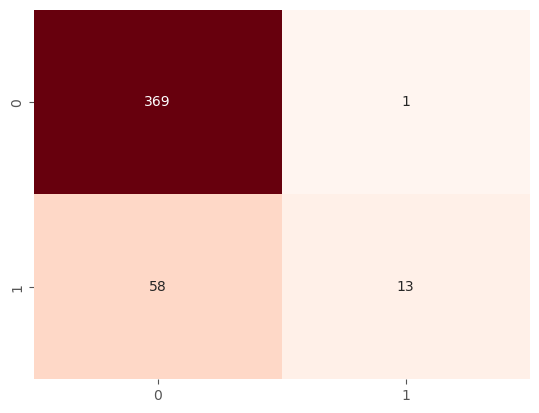

In [9]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Reds", cbar=False)
plt.show()

In [10]:
print("f1_score_train: ", metrics.f1_score(y_train, y_pred_train))
print("f1_score_test: ", metrics.f1_score(y_test, y_pred))

f1_score_train:  0.9815950920245399
f1_score_test:  0.3058823529411765


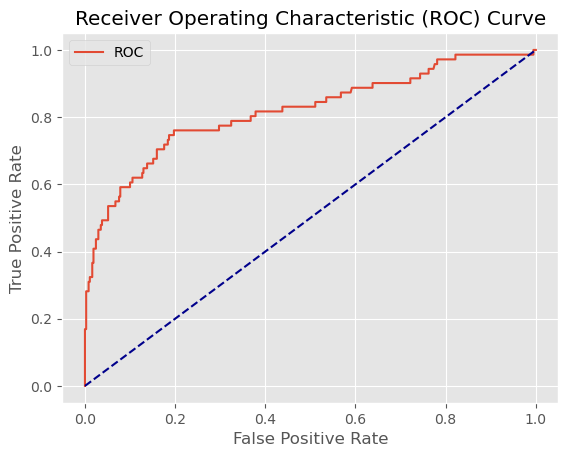

AUC: 0.82


In [11]:
rand_forest = RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=None, min_samples_split=5, min_samples_leaf=1)
rand_forest.fit(X_train, y_train)

y_probs = rand_forest.predict_proba(X_test)

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_probs[:, 1])

plt.plot(fpr, tpr, label='ROC')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

auc = metrics.roc_auc_score(y_test, y_probs[:, 1])
print('AUC: %.2f' % auc)

/var/folders/bx/jvqjgdsj5tq7bqvdpl9z20600000gn/T/ipykernel_38621/1956234004.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=rand_forest.feature_importances_, palette="Blues_d")


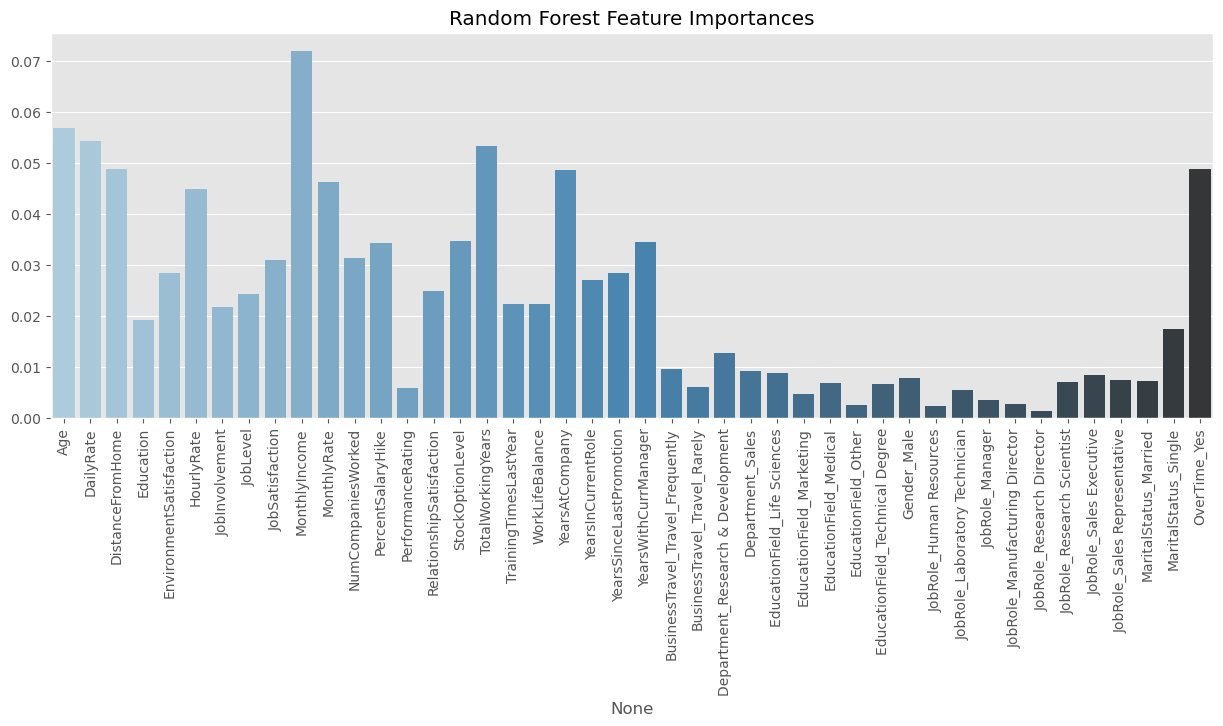

In [12]:
# Feature importance
plt.figure(figsize=(15, 5))
sns.barplot(x=X_train.columns, y=rand_forest.feature_importances_, palette="Blues_d")
plt.xticks(rotation=90)
plt.title('Random Forest Feature Importances')
plt.show()

## Adaboost

In [13]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

adaboost = AdaBoostClassifier(n_estimators=100, estimator=DecisionTreeClassifier(max_depth=3))
adaboost.fit(X_train, y_train)

y_pred = adaboost.predict(X_test)
y_pred_train = adaboost.predict(X_train)

print("f1_score_train: ", metrics.f1_score(y_train, y_pred_train))
print("f1_score_test: ", metrics.f1_score(y_test, y_pred))

f1_score_train:  1.0
f1_score_test:  0.5396825396825397


In [14]:
# GridSearch for AdaBoost
classifier = AdaBoostClassifier()
parameters = {'n_estimators': [50, 100, 200],
              'learning_rate': [0.0001, 0.01, 0.1, 1, 10]}

gs = GridSearchCV(classifier, parameters, cv=3, scoring='f1', verbose=10, n_jobs=-1, refit=True)
gs.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV 1/3; 1/15] START learning_rate=0.0001, n_estimators=50......................
[CV 2/3; 1/15] START learning_rate=0.0001, n_estimators=50......................
[CV 3/3; 1/15] START learning_rate=0.0001, n_estimators=50......................
[CV 1/3; 2/15] START learning_rate=0.0001, n_estimators=100.....................
[CV 2/3; 2/15] START learning_rate=0.0001, n_estimators=100.....................
[CV 3/3; 2/15] START learning_rate=0.0001, n_estimators=100.....................
[CV 1/3; 3/15] START learning_rate=0.0001, n_estimators=200.....................
[CV 2/3; 3/15] START learning_rate=0.0001, n_estimators=200.....................
[CV 3/3; 3/15] START learning_rate=0.0001, n_estimators=200.....................
[CV 1/3; 4/15] START learning_rate=0.01, n_estimators=50........................
[CV 2/3; 1/15] END learning_rate=0.0001, n_estimators=50;, score=0.000 total time=   0.1s
[CV 2/3; 4/15] START learning_rate=0.01

,estimator,AdaBoostClassifier()
,param_grid,"{'learning_rate': [0.0001, 0.01, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,estimator,None


In [15]:
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))

means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

***GRIDSEARCH RESULTS***
Best score: 0.424521 using {'learning_rate': 1, 'n_estimators': 200}
0.054054 (0.076444) with: {'learning_rate': 0.0001, 'n_estimators': 50}
0.054054 (0.076444) with: {'learning_rate': 0.0001, 'n_estimators': 100}
0.054054 (0.076444) with: {'learning_rate': 0.0001, 'n_estimators': 200}
0.000000 (0.000000) with: {'learning_rate': 0.01, 'n_estimators': 50}
0.000000 (0.000000) with: {'learning_rate': 0.01, 'n_estimators': 100}
0.000000 (0.000000) with: {'learning_rate': 0.01, 'n_estimators': 200}
0.000000 (0.000000) with: {'learning_rate': 0.1, 'n_estimators': 50}
0.000000 (0.000000) with: {'learning_rate': 0.1, 'n_estimators': 100}
0.035088 (0.028649) with: {'learning_rate': 0.1, 'n_estimators': 200}
0.294507 (0.101843) with: {'learning_rate': 1, 'n_estimators': 50}
0.364966 (0.018680) with: {'learning_rate': 1, 'n_estimators': 100}
0.424521 (0.025553) with: {'learning_rate': 1, 'n_estimators': 200}
0.054054 (0.076444) with: {'learning_rate': 10, 'n_estimators': 

In [16]:
#TEST ON YOUR TEST SET
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

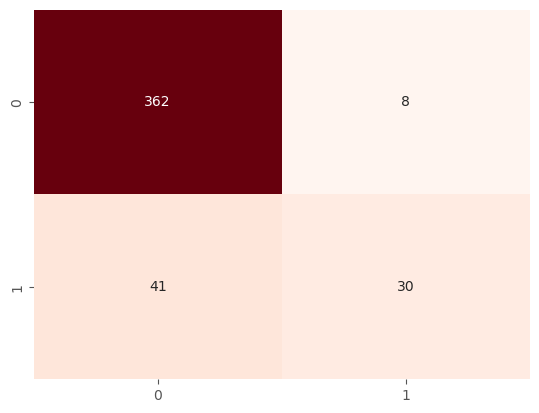

In [17]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Reds", cbar=False)
plt.show()

In [18]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       370
           1       0.79      0.42      0.55        71

    accuracy                           0.89       441
   macro avg       0.84      0.70      0.74       441
weighted avg       0.88      0.89      0.87       441



In [19]:
print("f1_score_train: ", metrics.f1_score(y_train, y_pred_train))
print("f1_score_test: ", metrics.f1_score(y_test, y_pred))

f1_score_train:  0.5826771653543307
f1_score_test:  0.5504587155963303


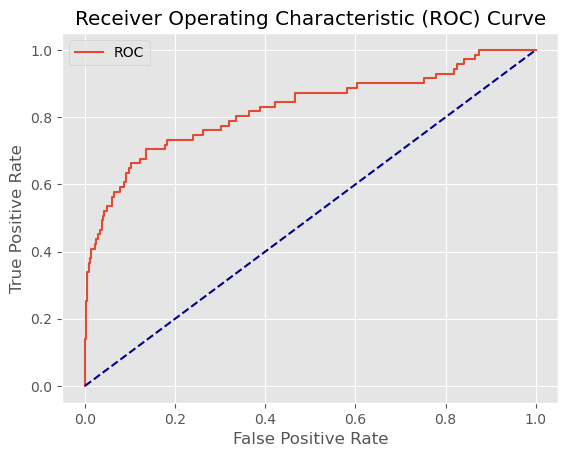

AUC: 0.83


In [20]:
# ROC curve
adaboost = AdaBoostClassifier(n_estimators=200, learning_rate=1)
adaboost.fit(X_train, y_train)

y_probs = adaboost.predict_proba(X_test)

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_probs[:, 1])

plt.plot(fpr, tpr, label='ROC')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

auc = metrics.roc_auc_score(y_test, y_probs[:, 1])
print('AUC: %.2f' % auc)

# Gradient Boosting

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

classifier = GradientBoostingClassifier()
parameters = {'n_estimators': [50, 100, 200],
              'learning_rate': [0.0001, 0.01, 0.1, 1, 10]}

gs = GridSearchCV(classifier, parameters, cv=3, scoring='f1', verbose=10, n_jobs=-1, refit=True)
gs.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV 1/3; 1/15] START learning_rate=0.0001, n_estimators=50......................
[CV 2/3; 1/15] START learning_rate=0.0001, n_estimators=50......................
[CV 3/3; 1/15] START learning_rate=0.0001, n_estimators=50......................
[CV 1/3; 2/15] START learning_rate=0.0001, n_estimators=100.....................
[CV 2/3; 2/15] START learning_rate=0.0001, n_estimators=100.....................
[CV 3/3; 2/15] START learning_rate=0.0001, n_estimators=100.....................
[CV 1/3; 3/15] START learning_rate=0.0001, n_estimators=200.....................
[CV 2/3; 3/15] START learning_rate=0.0001, n_estimators=200.....................
[CV 3/3; 3/15] START learning_rate=0.0001, n_estimators=200.....................
[CV 1/3; 4/15] START learning_rate=0.01, n_estimators=50........................
[CV 3/3; 1/15] END learning_rate=0.0001, n_estimators=50;, score=0.000 total time=   0.1s
[CV 2/3; 4/15] START learning_rate=0.01

,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': [0.0001, 0.01, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [22]:
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))

means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

***GRIDSEARCH RESULTS***
Best score: 0.365853 using {'learning_rate': 1, 'n_estimators': 50}
0.000000 (0.000000) with: {'learning_rate': 0.0001, 'n_estimators': 50}
0.000000 (0.000000) with: {'learning_rate': 0.0001, 'n_estimators': 100}
0.000000 (0.000000) with: {'learning_rate': 0.0001, 'n_estimators': 200}
0.000000 (0.000000) with: {'learning_rate': 0.01, 'n_estimators': 50}
0.034886 (0.028650) with: {'learning_rate': 0.01, 'n_estimators': 100}
0.149490 (0.011822) with: {'learning_rate': 0.01, 'n_estimators': 200}
0.262531 (0.031056) with: {'learning_rate': 0.1, 'n_estimators': 50}
0.303489 (0.050078) with: {'learning_rate': 0.1, 'n_estimators': 100}
0.296142 (0.046372) with: {'learning_rate': 0.1, 'n_estimators': 200}
0.365853 (0.068353) with: {'learning_rate': 1, 'n_estimators': 50}
0.352235 (0.029362) with: {'learning_rate': 1, 'n_estimators': 100}
0.330689 (0.023669) with: {'learning_rate': 1, 'n_estimators': 200}
0.230461 (0.039413) with: {'learning_rate': 10, 'n_estimators': 5

In [23]:
#TEST ON YOUR TEST SET
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

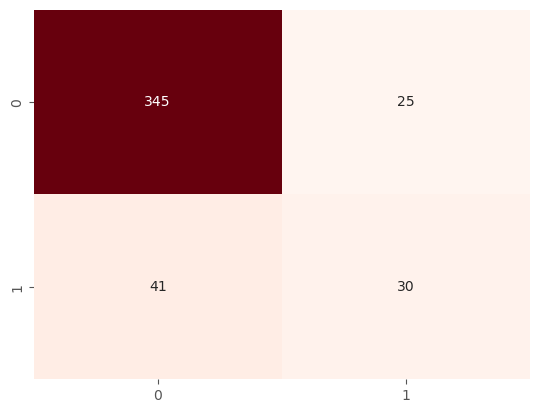

In [24]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Reds", cbar=False)
plt.show()

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91       370
           1       0.55      0.42      0.48        71

    accuracy                           0.85       441
   macro avg       0.72      0.68      0.69       441
weighted avg       0.84      0.85      0.84       441



In [26]:
print("f1_score_train: ", metrics.f1_score(y_train, y_pred_train))
print("f1_score_test: ", metrics.f1_score(y_test, y_pred))

f1_score_train:  1.0
f1_score_test:  0.47619047619047616


## Summary

In this notebook we explored three ensemble methods to predict employee attrition using the IBM HR dataset.

### Random Forest
- **F1 train = 0.98, F1 test = 0.31, AUC = 0.82** — severe overfitting despite tuning
- Top features: MonthlyIncome, Age, DailyRate, TotalWorkingYears — continuous variables dominate
- The forest memorizes the training set, struggling to generalize to the minority class

### AdaBoost
- **F1 train = 0.58, F1 test = 0.55, AUC = 0.83** — best ensemble result, minimal overfitting
- Best params: learning_rate=1, n_estimators=200
- The sequential boosting approach handles the class imbalance better than bagging

### Gradient Boosting
- **F1 train = 1.0, F1 test = 0.48, AUC = N/A** — severe overfitting, best params: learning_rate=1, n_estimators=50
- More estimators hurt performance at high learning rates — the model memorizes too quickly

Overall ensemble leaderboard:

| Model | F1 Test | AUC |
|-------|---------|-----|
| Random Forest | 0.31 | 0.82 |
| Gradient Boosting | 0.48 | N/A |
| AdaBoost | 0.55 | 0.83 |

Surprisingly, ensemble methods did not outperform Logistic Regression and SVM on this dataset. The class imbalance (84/16) remains the core challenge — techniques like SMOTE or class weighting could significantly improve all models in future work.

> One final note: Bagging and Boosting methods are not restricted to trees as weak learners — any base estimator can be used.